In [1]:
import analysis_functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Preparation
experiment_output_path = '/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output'

In [3]:
recent_results = analysis_functions.list_files_with_date_and_subject_id(experiment_output_path)

# The subject_id's and sessions to use are hardcoded for now

sub-002 did not complete session-01
sub-003 did not complete session-01


In [4]:
print(recent_results)

['/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output/experiment_output_sub-001_session-01_2024-04-10_13:37:11.csv']


In [5]:
combined_results_dataframe = analysis_functions.combine_result_files(recent_results)
print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        0        1.712749e+09     down                Even   
1        1        1.712749e+09       up                Even   
2        2        1.712749e+09       up                Even   
3        3        1.712749e+09       up                Even   
4        4        1.712749e+09      NaN                Even   
..     ...                 ...      ...                 ...   
475    475        1.712752e+09     down               False   
476    476        1.712752e+09     down               False   
477    477        1.712752e+09      NaN               False   
478    478        1.712752e+09       up               False   
479    479        1.712752e+09     down               False   

     subjectively_correct  response_time        RT  stimuli_type  iti  \
0                   False   1.712749e+09  0.947126             3  3.5   
1                   False   1.712749e+09  0.889028             2  3.5   
2                    Tru

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [6]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

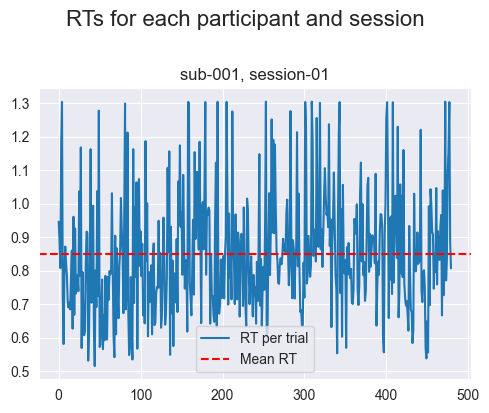

In [7]:
# Subplots for RT
## Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharex=True, sharey=True)
fig.suptitle('RTs for each participant and session', fontsize=16, y=1.02)

if n_rows == 1 or n_cols == 1:
    axes = np.array(axes).reshape(n_rows, n_cols)

## Loop through each combination of 'session' and 'subject_id' and create a plot
for i, session in enumerate(unique_sessions):
    for j, subject_id in enumerate(unique_subject_ids):
        ax_index = j * len(unique_sessions) + i
        ax = axes[j, i]

        ## Filter the dataframe for the current session and subject_id
        subset = combined_results_dataframe[(combined_results_dataframe['session'] == session) & (combined_results_dataframe['subject_id'] == subject_id)]

        ## Plot
        ax.plot(subset['RT'].values, label=f'RT per trial')
        ax.axhline(subset['RT'].mean(), color='r', linestyle='--', label='Mean RT')
        ax.set_title(f'{subject_id}, {session}')
        ax.legend()

## Adjust layout
plt.tight_layout()
plt.show()

In [8]:
# Create a dataframe with average objectively correct responses
## Filter out 50% trials
combined_results_dataframe_filtered = combined_results_dataframe[(combined_results_dataframe['probability_condition'] != 50) & (combined_results_dataframe['objectively_correct'] != 'Even')]

## Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0}
combined_results_dataframe_filtered['objectively_correct_boolean'] = combined_results_dataframe_filtered['objectively_correct'].replace(mapping)
pd.options.display.max_rows = None
combined_results_dataframe_filtered['objectively_correct_boolean'] = combined_results_dataframe_filtered['objectively_correct_boolean'].astype('int')
combined_results_dataframe_filtered['objectively_correct_boolean'] *= 100

## Create new dataframe with average responses per subject_id and session
combined_results_dataframe_filtered_1 = combined_results_dataframe_filtered[combined_results_dataframe_filtered['stimuli_type'] == 1]
combined_results_dataframe_filtered_2 = combined_results_dataframe_filtered[combined_results_dataframe_filtered['stimuli_type'] == 2]
combined_results_dataframe_filtered_3 = combined_results_dataframe_filtered[combined_results_dataframe_filtered['stimuli_type'] == 3]
combined_results_dataframe_filtered_4 = combined_results_dataframe_filtered[combined_results_dataframe_filtered['stimuli_type'] == 4]

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_50931/926276223.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_results_dataframe_filtered['objectively_correct_boolean'] = combined_results_dataframe_filtered['objectively_correct'].replace(mapping)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_50931/926276223.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_filtered['objectively_correct_boolean'] = combined_results_dataframe_filtered['objectively_correct

In [9]:
## Add indeces of switches
combined_results_dataframe_filtered_1['switch'] = combined_results_dataframe_filtered_1['probability_condition'].diff().ne(0)


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_50931/3036253169.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_filtered_1['switch'] = combined_results_dataframe_filtered_1['probability_condition'].diff().ne(0)


In [10]:
# Objectively correct choice
plt.figure(figsize=(10, 6))
sns.barplot(x='session', y='objectively_correct_boolean', hue='subject_id', data=objectively_correct_average_dataframe, errorbar=None)

plt.title('Objectively correct choices for each participant and session')
plt.ylabel('Objectively correct choices [%]')
plt.xlabel('Sessions')
plt.legend(title='Subjects')

plt.show()

NameError: name 'objectively_correct_average_dataframe' is not defined

<Figure size 1000x600 with 0 Axes>